outlier removal using IQR(interquartile range)


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
dataset = pd.read_csv(r"C:\Users\hp\Downloads\new loan dataset\test_Y3wMUE5_7gLdaTN.csv")

In [4]:
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


In [5]:
dataset.isnull().sum()

Loan_ID               0
Gender               11
Married               0
Dependents           10
Education             0
Self_Employed        23
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            5
Loan_Amount_Term      6
Credit_History       29
Property_Area         0
dtype: int64

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


In [7]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


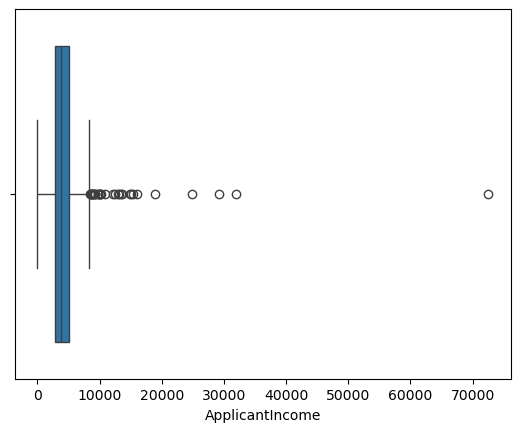

In [9]:
sns.boxplot(x = "ApplicantIncome",data=dataset)
plt.show()

In [10]:
dataset.shape

(367, 12)

In [14]:
q1 = dataset["ApplicantIncome"].quantile(0.25)

In [15]:
q1

2864.0

In [16]:
q3 = dataset["ApplicantIncome"].quantile(0.75)

In [17]:
q3

5060.0

In [18]:
dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


In [19]:
iqr = q3-q1

In [20]:
min_range = q1-(1.5*iqr)
max_range = q3-(1.5*iqr)
min_range,max_range

(-430.0, 1766.0)

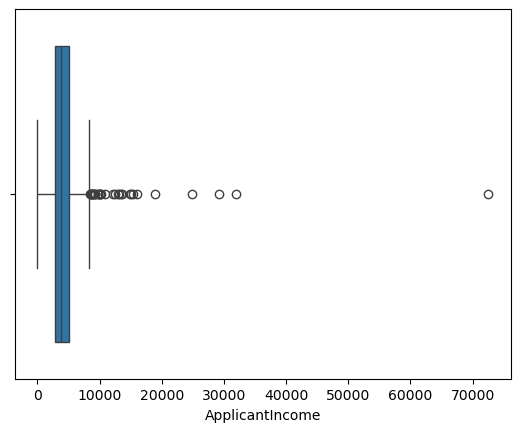

In [21]:
plt.figure(figure = (15,10))
sns.boxplot(x = "ApplicantIncome",data = dataset)
plt.show()

In [22]:
dataset[dataset["ApplicantIncome"]<=max_range]

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
19,LP001115,Male,No,0,Graduate,No,1300,3470,100.0,180.0,1.0,Semiurban
25,LP001153,Male,No,0,Graduate,No,0,24000,148.0,360.0,0.0,Rural
42,LP001226,Male,Yes,0,Not Graduate,No,1750,2024,90.0,360.0,1.0,Semiurban
106,LP001563,NaN,No,0,Graduate,No,1596,1760,119.0,360.0,0.0,Urban
116,LP001607,Female,No,0,Not Graduate,No,0,1760,180.0,360.0,1.0,Semiurban
117,LP001611,Male,Yes,1,Graduate,No,1516,2900,80.0,NaN,0.0,Rural
118,LP001613,Female,No,0,Graduate,No,1762,2666,104.0,360.0,0.0,Urban
119,LP001622,Male,Yes,2,Graduate,No,724,3510,213.0,360.0,0.0,Rural
155,LP001857,Male,No,0,Not Graduate,Yes,1599,2474,125.0,300.0,1.0,Semiurban
166,LP001933,Male,No,2,Not Graduate,No,1141,2017,120.0,360.0,0.0,Urban


In [23]:
new_dataset = dataset[dataset["ApplicantIncome"]<=max_range]

In [24]:
new_dataset.shape

(17, 12)

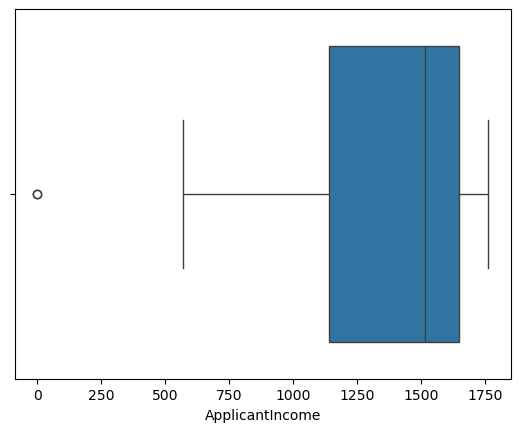

In [25]:
sns.boxplot(x="ApplicantIncome",data = new_dataset)
plt.show()